# Power plant analysis

Base: [Source](https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/network_analysis.ipynb)

Adapted: Alexander Meisinger, OTH Regensburg

In [2]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy
import warnings

### Own country analysis

In [3]:
# Network file
results_path = "/mnt/e/HySEE/Bulgaria/pypsa-earth/results/144h/networks/elec_s_10_ec_lcopt_Co2L0.45-144h.nc"
network_path = "/mnt/e/HySEE/Bulgaria/pypsa-earth/networks/144h/elec.nc"

# Country shape file
regions_onshore_path = "/mnt/e/HySEE/Bulgaria/pypsa-earth/resources/shapes/country_shapes.geojson"
# Renewable profile file
solar_path = "/mnt/e/HySEE/Bulgaria/pypsa-earth/resources/renewable_profiles/profile_solar.nc"
onwind_path = "/mnt/e/HySEE/Bulgaria/pypsa-earth/resources/renewable_profiles/profile_onwind.nc"

### Energy system analysis setup - power and energy generation

In [4]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L0.45-144h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401


### Data import check: Country check

Text(0.5, 1.0, 'BG')

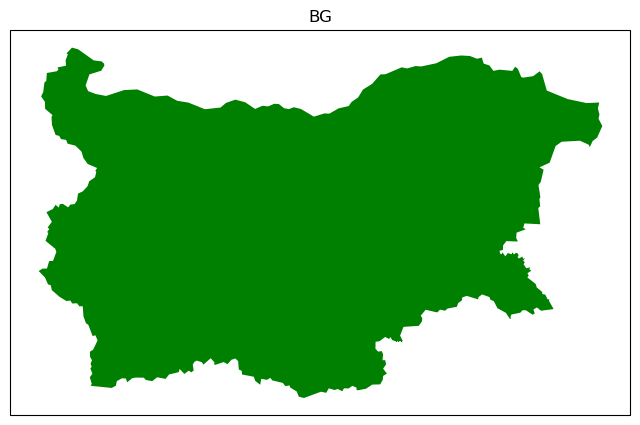

In [5]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [6]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 84 entries
Component 'Carrier' has 23 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 56 entries
Component 'LineType' has 35 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 112 entries
Component 'Load' has 28 entries
Component 'Generator' has 158 entries
Component 'StorageUnit' has 7 entries
Component 'Store' has 56 entries


Snapshot check

In [7]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-07', '2013-01-13', '2013-01-19',
               '2013-01-25', '2013-01-31', '2013-02-06', '2013-02-12',
               '2013-02-18', '2013-02-24', '2013-03-02', '2013-03-08',
               '2013-03-14', '2013-03-20', '2013-03-26', '2013-04-01',
               '2013-04-07', '2013-04-13', '2013-04-19', '2013-04-25',
               '2013-05-01', '2013-05-07', '2013-05-13', '2013-05-19',
               '2013-05-25', '2013-05-31', '2013-06-06', '2013-06-12',
               '2013-06-18', '2013-06-24', '2013-06-30', '2013-07-06',
               '2013-07-12', '2013-07-18', '2013-07-24', '2013-07-30',
               '2013-08-05', '2013-08-11', '2013-08-17', '2013-08-23',
               '2013-08-29', '2013-09-04', '2013-09-10', '2013-09-16',
               '2013-09-22', '2013-09-28', '2013-10-04', '2013-10-10',
               '2013-10-16', '2013-10-22', '2013-10-28', '2013-11-03',
               '2013-11-09', '2013-11-15', '2013-11-21', '2013-11-27',
      

### Analyse the current capacity of the energy system - map view

/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


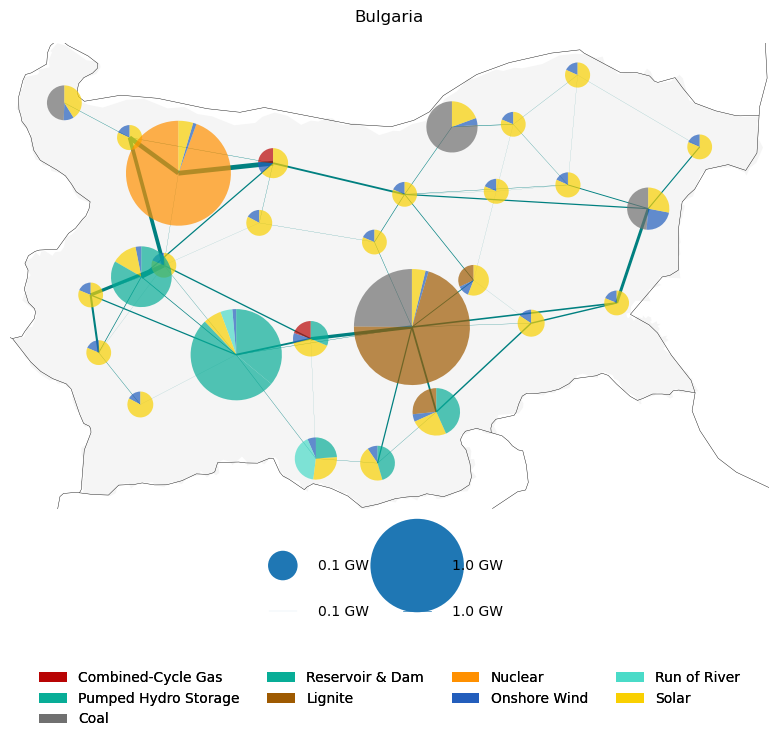

In [9]:
legend_kwargs = {
    "loc": "upper left",
    "frameon": False,
    "prop": {
        "family": "DejaVu Sans",
        "size": 12,
        "weight": "normal",
    },
}

# Scale settings
bus_scale = 1.5e4 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100,1000]  # in MW

#n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(16, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export") & (n.generators.carrier != "load shedding")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.6), "labelspacing": 2, **legend_kwargs}

# Installed capacities by carrier (generators + storage)
carrier_cap = pd.concat([
    n.generators.groupby("carrier").p_nom.sum(),
    n.storage_units.groupby("carrier").p_nom.sum(),
]).groupby(level=0).sum()

carrier_cap = carrier_cap.drop("load shedding", errors="ignore")

# Keep only carriers with capacity > 0
used_carriers = carrier_cap[carrier_cap > 0].index

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.08),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,   # Abstand zwischen den beiden Einträgen
        "handletextpad": 1.0,   # Abstand Symbol ↔ Text
    },
)
leg_lines  = add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.18),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,   # Abstand zwischen den beiden Einträgen
        "handletextpad": 1.0,   # Abstand Symbol ↔ Text
        #"handlelength": 1,   # Standard ~2.0
    },
)

# nur die beiden Striche nach links verschieben
leg = ax.get_legend() if leg_lines is None else leg_lines

for h in leg.legend_handles:
    h.set_xdata(np.array(h.get_xdata()) - 5)  # größerer Wert = weiter links

add_legend_patches(
    ax,
    n.carriers.loc[used_carriers, "color"],
    n.carriers.loc[used_carriers, "nice_name"],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.5, -0.32),
        "frameon": False,
        "ncol": 4,
    },
)

ax.set_title(
    "Bulgaria",
    fontfamily="DejaVu Sans",
    fontsize=12,
    fontweight="normal",
    pad=15,
    x=0.5
)

fig.tight_layout()

### Analyse the current generation capacity of the energy system - pie chart view

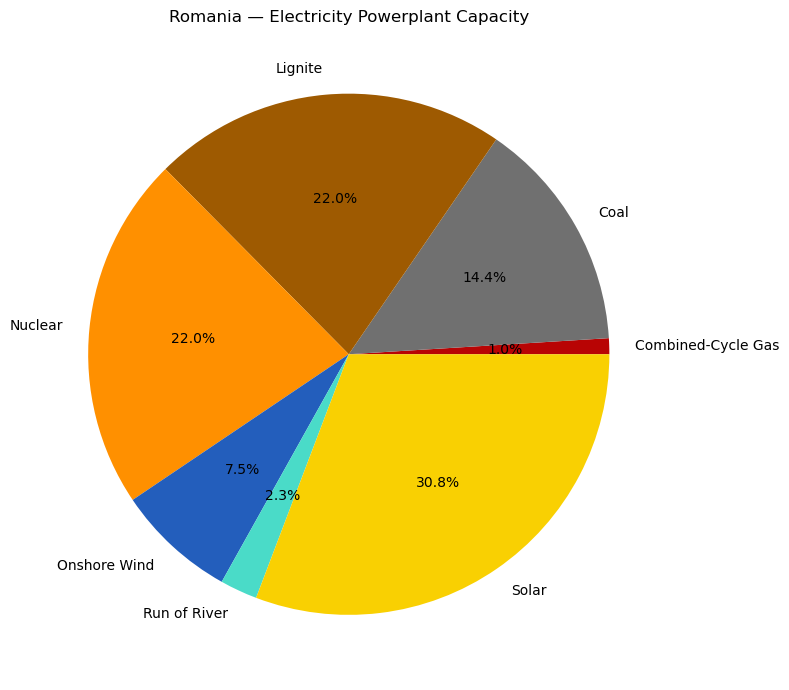

In [10]:
generator_capacity_by_carrier = (
    n.generators[
        (n.generators.carrier != "load") &
        (n.generators.carrier != "export") &
        (n.generators.carrier != "load shedding")
    ]
    .groupby("carrier")
    .p_nom.sum()
)

generator_capacity_by_carrier = generator_capacity_by_carrier[
    generator_capacity_by_carrier > 0
]

# Nice names
labels = n.carriers.loc[
    generator_capacity_by_carrier.index,
    "nice_name"
]

fig, ax = plt.subplots(figsize=(8, 8))

ax.pie(
    generator_capacity_by_carrier,
    labels=labels,
    autopct="%1.1f%%",
    colors=n.carriers.loc[
        generator_capacity_by_carrier.index,
        "color"
    ],
)

ax.set_title(
    "Romania — Electricity Powerplant Capacity",
    fontfamily="DejaVu Sans",
    fontsize=12,
    fontweight="normal",
    pad=5,
)

plt.tight_layout()

### Analyse the current gernation capacity of the energy system - tabular view

In [11]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT       0.09300
coal       1.36400
lignite    2.07800
nuclear    2.08000
onwind     0.70431
ror        0.21900
solar      2.90813
Name: p_nom, dtype: float64

### Common country analysis

INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/pyogrio/__init__.py:7: DeprecationWarning: The 'shapely.geos' module is deprecated, and will be removed in a future version. All attributes of 'shapely.geos' are available directly from the top-level 'shapely' namespace (since shapely 2.0.0).
  import shapely.geos  # noqa: F401
INFO:pypsa.io:Imported network elec_s_10_ec_lcopt_Co2L-1h.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/alex-charly/anaconda3/envs/pypsa-earth-HySEE-BG/lib/python

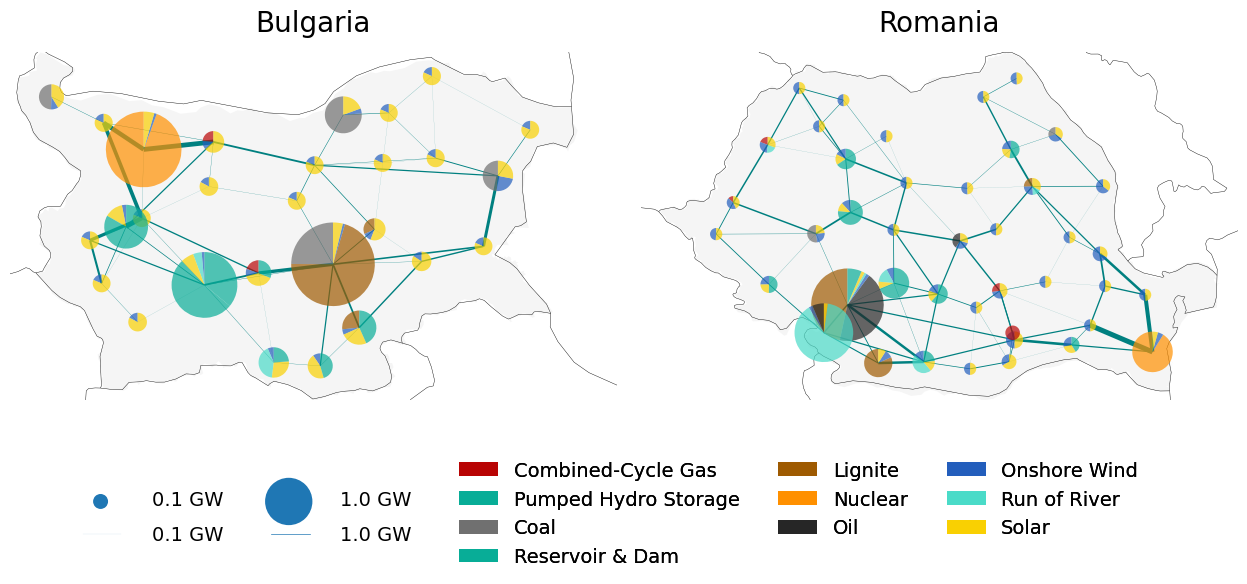

In [1]:
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import pypsa
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches


# Paths
results_path_BG = "/mnt/e/HySEE/Bulgaria/pypsa-earth/results/networks/elec_s_10_ec_lcopt_Co2L-1h.nc"
regions_onshore_path_BG = "/mnt/e/HySEE/Bulgaria/pypsa-earth/resources/shapes/country_shapes.geojson"

results_path_RO = "/mnt/e/HySEE/Romania/pypsa-earth/results/networks/elec_s_10_ec_lcopt_Co2L-1h.nc"
regions_onshore_path_RO = "/mnt/e/HySEE/Romania/pypsa-earth/resources/shapes/country_shapes.geojson"


# Load networks and shapes
warnings.simplefilter(action="ignore", category=FutureWarning)

n_BG = pypsa.Network(results_path_BG)
regions_onshore_BG = gpd.read_file(regions_onshore_path_BG)

n_RO = pypsa.Network(results_path_RO)
regions_onshore_RO = gpd.read_file(regions_onshore_path_RO)

warnings.simplefilter(action="default", category=FutureWarning)


# Scale settings
bus_scale = 1.5e4
line_scale = 2e3

bus_sizes = [100, 1000]       # MW
line_sizes = [100, 1000]      # MW


# Figure
fig, (ax_BG, ax_RO) = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    subplot_kw={"projection": ccrs.EqualEarth()},
)

plot_data = [
    (ax_BG, n_BG, regions_onshore_BG, "Bulgaria"),
    (ax_RO, n_RO, regions_onshore_RO, "Romania"),
]


for ax, n, regions_onshore, title in plot_data:

    gen = n.generators[
        (n.generators.carrier != "load")
        & (n.generators.carrier != "export")
        & (n.generators.carrier != "load shedding")
    ].groupby(["bus", "carrier"]).p_nom.sum()

    sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()

    buses = pd.concat([gen, sto])

    with plt.rc_context({"patch.linewidth": 0.}):
        n.plot(
            bus_sizes=buses / bus_scale,
            bus_alpha=0.7,
            line_widths=n.lines.s_nom_opt / line_scale,
            link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
            line_colors="teal",
            ax=ax,
            margin=0.2,
            color_geomap=None,
        )

    regions_onshore.plot(
        ax=ax,
        facecolor="whitesmoke",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=0,
    )

    ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

    ax.set_title(
        title,
        fontfamily="DejaVu Sans",
        fontsize=20,
        fontweight="normal",
        pad=15,
    )


# Common carrier legend from both countries
carrier_cap_BG = pd.concat([
    n_BG.generators.groupby("carrier").p_nom.sum(),
    n_BG.storage_units.groupby("carrier").p_nom.sum(),
]).groupby(level=0).sum()

carrier_cap_RO = pd.concat([
    n_RO.generators.groupby("carrier").p_nom.sum(),
    n_RO.storage_units.groupby("carrier").p_nom.sum(),
]).groupby(level=0).sum()

carrier_cap = pd.concat([carrier_cap_BG, carrier_cap_RO]).groupby(level=0).sum()
carrier_cap = carrier_cap.drop("load shedding", errors="ignore")
used_carriers = carrier_cap[carrier_cap > 0].index


# Legends below both maps
add_legend_circles(
    ax_BG,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.4, -0.21),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,
        "handletextpad": 1.0,
        "prop": {
            "family": "DejaVu Sans",
            "size": 14,
            "weight": "normal",
        },
    },
)

leg_lines = add_legend_lines(
    ax_BG,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (0.4, -0.31),
        "frameon": False,
        "ncol": 2,
        "columnspacing": 3.0,
        "handletextpad": 1.0,
        "prop": {
            "family": "DejaVu Sans",
            "size": 14,
            "weight": "normal",
        },
    },
)

leg = ax_BG.get_legend() if leg_lines is None else leg_lines

for h in leg.legend_handles:
    h.set_xdata(np.array(h.get_xdata()) - 8)


# Use carrier colors from BG network; fall back to RO if needed
carrier_colors = n_BG.carriers.reindex(used_carriers)["color"].fillna(
    n_RO.carriers.reindex(used_carriers)["color"]
)

carrier_names = n_BG.carriers.reindex(used_carriers)["nice_name"].fillna(
    n_RO.carriers.reindex(used_carriers)["nice_name"]
)

add_legend_patches(
    ax_BG,
    carrier_colors,
    carrier_names,
    legend_kw={
        "loc": "upper center",
        "bbox_to_anchor": (1.3, -0.125),
        "frameon": False,
        "ncol": 3,
        "prop": {
            "family": "DejaVu Sans",
            "size": 14,
            "weight": "normal",
        },
    },
)


fig.subplots_adjust(
    wspace=0.02,
    bottom=0.30,
)

plt.show()